# Finite-temperature stability of W–Mo–Se–S monolayers

This notebook evaluates finite-temperature stability through configurational free energies, cell-size sensitivity and vibrational contributions. It starts with the included **2×2×1 DFT CCS** (11,159 configurations, 420 compositions), then examines the **4×4×1 second inference CCS**, and finally assesses vibrational contributions for six quaternary targets.

The default run uses compact inputs already in the repository. Recomputing the second-inference free energies is optional and requires the large GNN prediction dataset. Python helpers in `analysis/` hold the shared numerical and plotting functions; the steps, assumptions and results are presented here.

[Repository guide](README.md) · [Previous analysis](holdout_test_2.ipynb) · [Phonon calculation records](phonons_results/README.md)

## Contents

1. [Setup and inputs](#setup-and-inputs)
2. [Configurational free energy](#configurational-free-energy)
3. [Full 2×2×1 hull](#full-2x2x1-hull)
4. [Vacancy-free hull](#vacancy-free-hull)
5. [Second inference CCS](#second-inference-ccs)
6. [Optional GNN recomputation](#optional-gnn-recomputation)
7. [Effective cell size](#effective-cell-size)
8. [Phonon acceptance gates](#phonon-acceptance-gates)
9. [Moving tie planes](#moving-tie-planes)
10. [Onset shifts](#onset-shifts)
11. [Exported results](#exported-results)

<a id="setup-and-inputs"></a>
## Setup and inputs

Install the root `requirements.txt` and launch Jupyter from the repository root. Generated tables and figures are saved to `results/finite_temperature/`. The optional `GRAPHHULL_OUTPUT_DIR` environment variable redirects generated outputs.

The analysis uses a 10 K grid over 0–1200 K, ordered elemental reference vertices at zero formation energy, and an on-hull tolerance of **1e-9 eV/atom = 1e-6 meV/atom**. The combined training/2DMD 0 K reference in `convex_hull_analysis.ipynb` is a separate reference set and is not pooled into these hulls.

In [1]:
%matplotlib inline

from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from analysis.thermodynamics import (
    ELEMENTS, TEMPERATURES, HULL_TOLERANCE_EV,
    build_free_energy_table, temperature_hulls, hull_distance_table,
    long_result_table, prepare_gnn_configurations, read_dft_minima,
    validate_dft_minima, simplex_basis, transform_composition,
)
from analysis.finite_size import size_sensitivity, entropy_deficits
from analysis.phonons import (
    build_vibrational_table, account_facets, select_facets, onset_shifts, scoped_statistics,
)
from analysis.figures.onsets import plot_mow, plot_sse
from analysis.figures.quaternary import plot_quaternary
from analysis.figures.vibrational import plot_vibrational

root = Path.cwd()
if not (root / 'data/ccs_2x2x1_full_energetics.csv').is_file():
    raise FileNotFoundError('Launch Jupyter from the 2DMaterialsGraphHull repository root')
data_dir = root / 'data'
ft_data = data_dir / 'finite_temperature'
phonon_data = data_dir / 'phonons'
output_dir = Path(os.environ.get('GRAPHHULL_OUTPUT_DIR', 'results/finite_temperature'))
output_dir.mkdir(parents=True, exist_ok=True)

run_full_gnn = False
model = 'nequip_random_ccs'
apply_dft_minimum_correction = True
inference_file = data_dir / 'inference2_ccs-gnn_predictions_subset.pkl.gz'
dft_minimum_file = data_dir / 'inference2_ccs-dft-minima.pkl.gz'
gnn_result_file = data_dir / 'inference2_ccs-finite_temperature_hull.pkl.gz'
temperatures = TEMPERATURES.copy()
hull_tolerance = HULL_TOLERANCE_EV
print(f'{len(temperatures)} temperatures; hull tolerance {hull_tolerance:g} eV/atom')

121 temperatures; hull tolerance 1e-09 eV/atom


In [2]:
ccs = pd.read_csv(data_dir / 'ccs_2x2x1_full_energetics.csv')
print(f'{len(ccs):,} configurations; {ccs.groupby(ELEMENTS).ngroups} compositions')
display(ccs[['formula', 'n_atoms', 'n_vac_Me', 'n_vac_X', 'weight', 'E_form_eV_per_atom']].head())

11,159 configurations; 420 compositions


,formula,n_atoms,n_vac_Me,n_vac_X,weight,E_form_eV_per_atom
0,W4Se8,12,0,0,1,-0.555926
1,W1Mo3Se1S3,8,0,4,8,0.077294
2,W1Mo3Se1S3,8,0,4,8,0.265183
3,W1Mo3Se4S4,12,0,0,12,-0.763212
4,W1Mo3Se4S4,12,0,0,12,-0.759673


<a id="configurational-free-energy"></a>
## Configurational free energy

For each composition, the symmetry weights count the atomic arrangements represented by every CCS entry:

$$G_{conf}(T)/N = [E_{min}^{cell} - k_BT\ln\sum_i w_i\exp(-(E_i^{cell}-E_{min}^{cell})/(k_BT))]/N.$$

The input formation energies are **eV/atom** and are multiplied by the number of real atoms before the partition sum. Subtracting the minimum stabilizes the exponential numerically; at 0 K the result is the minimum energy per atom. Vacancies enter the site counts and symmetry weights, but do not count as atoms in the denominator. This stage contains configurational contributions only.

In [3]:
full_metadata, full_free_energy = build_free_energy_table(ccs, temperatures)
preview = full_metadata[['formula', 'n_configs', 'sum_weight', 'n_vac_Me', 'n_vac_X']].copy()
preview['G_0K_eV_atom'] = full_free_energy[:, 0]
preview['G_1200K_eV_atom'] = full_free_energy[:, -1]
display(preview.head())

,formula,n_configs,sum_weight,n_vac_Me,n_vac_X,G_0K_eV_atom,G_1200K_eV_atom
0,W0Mo2Se0S4,16,420.0,2,4,-0.438017,-0.525545
1,W0Mo2Se0S5,10,336.0,2,3,-0.464776,-0.532252
2,W0Mo2Se0S6,8,168.0,2,2,-0.384599,-0.437360
3,W0Mo2Se0S7,2,48.0,2,1,-0.226384,-0.263920
4,W0Mo2Se0S8,1,6.0,2,0,-0.137641,-0.156170


<a id="full-2x2x1-hull"></a>
## Full 2×2×1 hull

Rebuild the lower convex hull from the 420 composition free energies at every temperature, adding the four ordered elemental vertices. Report the distance above that moving reference in meV/atom. An onset is the first **grid** temperature at which a composition reaches the hull; a missing onset means that it never reaches the hull within 0–1200 K.

The included wide table is a rounded publication export. Compare the recomputed distances against that export before proceeding.

In [4]:
full_hull = temperature_hulls(full_metadata, full_free_energy, temperatures, hull_tolerance)
full_wide = hull_distance_table(full_metadata, full_hull, temperatures)
full_wide.to_csv(output_dir / 'ft_hull_2x2x1.csv', index=False, float_format='%.4f')
reference_full = pd.read_csv(ft_data / 'ft_hull_2x2x1.csv').set_index('formula').loc[full_metadata.formula]
delta_columns = [f'dGhull_{int(t)}K' for t in temperatures]
max_delta = np.max(np.abs(full_wide[delta_columns].to_numpy() - reference_full[delta_columns].to_numpy()))
if max_delta > 5.1e-5:
    raise ValueError(f'Full-hull regression failed: {max_delta:g} meV/atom')
print(f'Full-hull reproduction: max difference {max_delta:.3g} meV/atom (4-decimal source export)')
display(full_wide[['formula', 'n_elements', 'n_vac_Me', 'n_vac_X', 'onset_T_K']].head())

Full-hull reproduction: max difference 5e-05 meV/atom (4-decimal source export)


,formula,n_elements,n_vac_Me,n_vac_X,onset_T_K
0,W0Mo2Se0S4,2,2,4,NaN
1,W0Mo2Se0S5,2,2,3,NaN
2,W0Mo2Se0S6,2,2,2,NaN
3,W0Mo2Se0S7,2,2,1,NaN
4,W0Mo2Se0S8,2,2,0,NaN


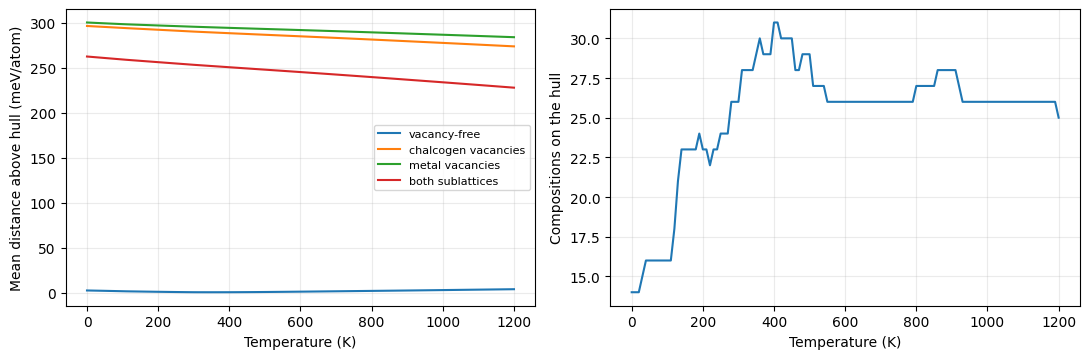

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.7))
classes = {
    'vacancy-free': (full_metadata.n_vac_Me == 0) & (full_metadata.n_vac_X == 0),
    'chalcogen vacancies': (full_metadata.n_vac_Me == 0) & (full_metadata.n_vac_X > 0),
    'metal vacancies': (full_metadata.n_vac_Me > 0) & (full_metadata.n_vac_X == 0),
    'both sublattices': (full_metadata.n_vac_Me > 0) & (full_metadata.n_vac_X > 0),
}
for label, mask in classes.items():
    axes[0].plot(temperatures, full_hull['above'][mask].mean(axis=0) * 1000, label=label)
axes[0].set(xlabel='Temperature (K)', ylabel='Mean distance above hull (meV/atom)')
axes[0].legend(fontsize=8)
axes[1].plot(temperatures, full_hull['on_hull'].sum(axis=0))
axes[1].set(xlabel='Temperature (K)', ylabel='Compositions on the hull')
for ax in axes:
    ax.grid(alpha=.25)
fig.tight_layout()
plt.show()

<a id="vacancy-free-hull"></a>
## Vacancy-free hull

Restrict the composition set to the 45 vacancy-free compositions and rebuild the hull independently. A vacancy in the 2×2×1 cell corresponds to a large vacant fraction (25% of metal sites or 12.5% of chalcogen sites). Entropy from these phases can change the full hull substantially. The phonon tie-plane analysis is defined on the vacancy-free branch and uses this second hull throughout.

Vacancy-free hull: 45 compositions; max difference 5e-05 meV/atom
21 vacancy-free quaternary compositions


wrote figure_quaternary_onhull_vacancyfree.pdf / .png
  reach the hull: 21/21; earliest 230 K
  widest on-hull window: 81 % of the 0-1200 K range


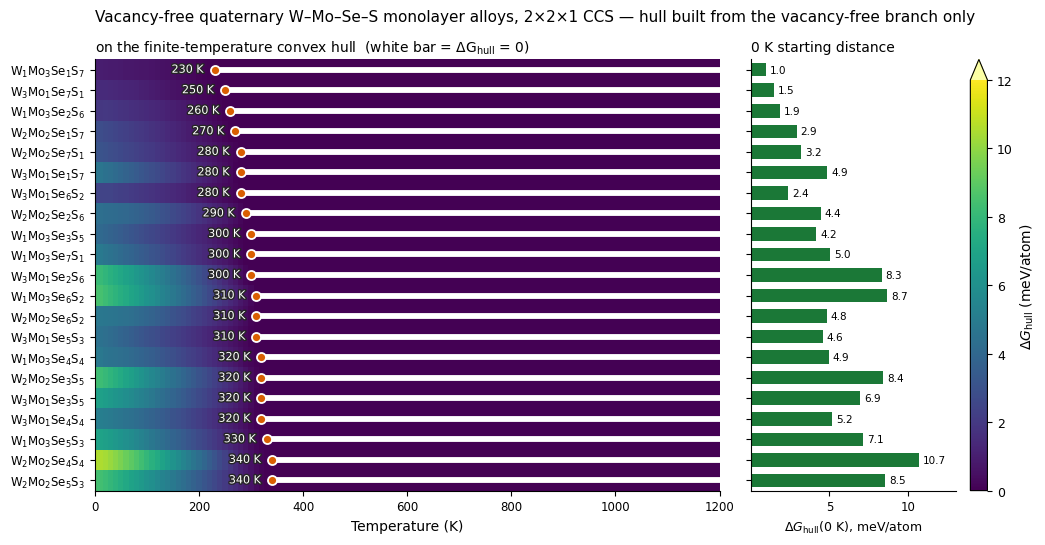

In [6]:
vf_metadata, vf_free_energy = build_free_energy_table(ccs, temperatures, vacancy_free=True)
vf_hull = temperature_hulls(vf_metadata, vf_free_energy, temperatures, hull_tolerance)
vf_wide = hull_distance_table(vf_metadata, vf_hull, temperatures)
vf_wide.to_csv(output_dir / 'ft_hull_2x2x1_vacancyfree.csv', index=False, float_format='%.4f')
reference_vf = pd.read_csv(ft_data / 'ft_hull_2x2x1_vacancyfree.csv')
expected = reference_vf.set_index('formula').loc[vf_metadata.formula, delta_columns].to_numpy()
max_delta_vf = np.max(np.abs(vf_wide[delta_columns].to_numpy() - expected))
if max_delta_vf > 5.1e-5:
    raise ValueError('Vacancy-free hull regression failed')
print(f'Vacancy-free hull: {len(vf_metadata)} compositions; max difference {max_delta_vf:.3g} meV/atom')
fig = plot_quaternary(output_dir / 'ft_hull_2x2x1_vacancyfree.csv', output_dir)
display(fig)
plt.close(fig)

<a id="second-inference-ccs"></a>
## Second inference CCS

The included `fi_onsets.csv` contains postprocessed **DFT-anchored** GNN hull distances for 544 compositions in the 4×4×1 second inference CCS. It is enough to reproduce the stability maps and count stabilization onsets. It contains neither absolute free energies nor individual GNN predictions, so it cannot be used to rebuild a differently corrected hull or extrapolate its configurational stabilization to a new cell size.

Configuration counts and symmetry-weight sums describe complete and reduced inference subsets. Figures 6d and S23 use the vacancy-free rows of the full second-inference hull.

,class_name,compositions,reach_hull,first_onset_K,median_onset_K
0,vacancy-free,184,107,0.0,60.0
1,one chalcogen vacancy,180,0,NaN,NaN
2,one metal vacancy,180,0,NaN,NaN


wrote fig441_6d_MoW: 68 compositions, 1 never on hull, median onset 30 K, max 1190 K


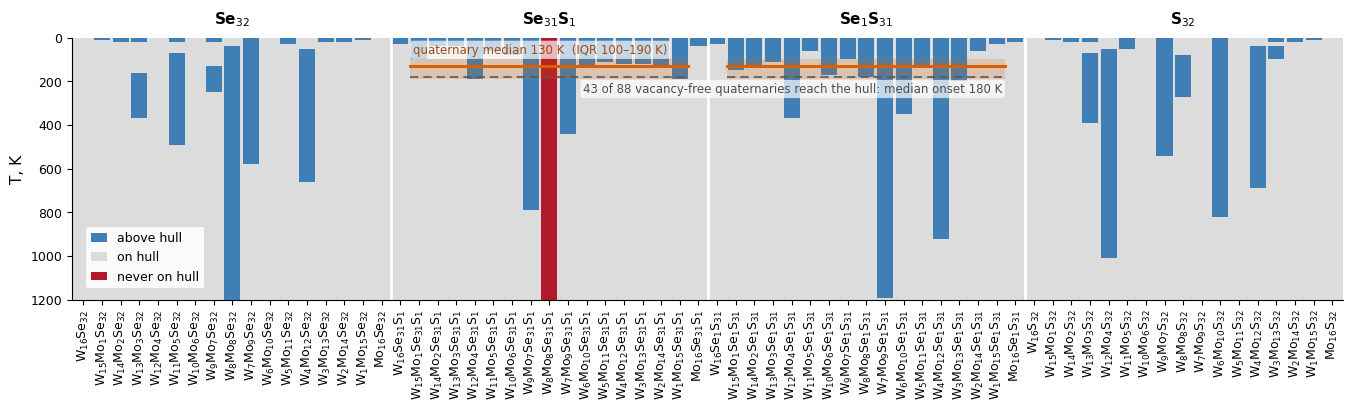

wrote fig441_6d_SSe


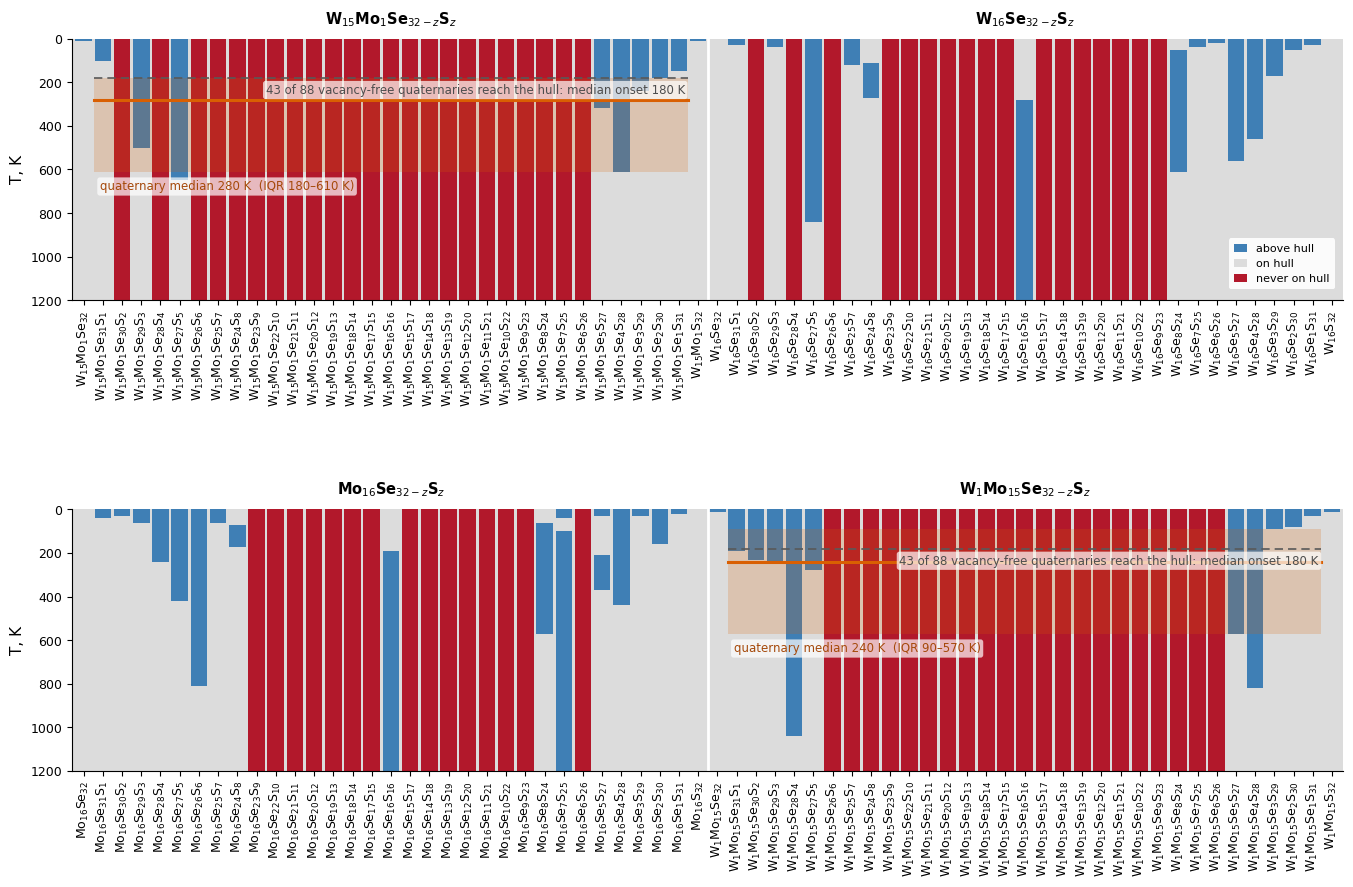

In [7]:
cached_441 = pd.read_csv(ft_data / 'fi_onsets.csv', index_col=0)
rows = []
for label, mask in {
    'vacancy-free': (cached_441.n_vac_Me == 0) & (cached_441.n_vac_X == 0),
    'one chalcogen vacancy': (cached_441.n_vac_Me == 0) & (cached_441.n_vac_X == 1),
    'one metal vacancy': (cached_441.n_vac_Me == 1) & (cached_441.n_vac_X == 0),
}.items():
    subset = cached_441[mask]
    reached = subset.onset_T_K.dropna()
    rows.append(dict(class_name=label, compositions=len(subset), reach_hull=len(reached),
                     first_onset_K=reached.min(), median_onset_K=reached.median()))
display(pd.DataFrame(rows))
for plot in (plot_mow, plot_sse):
    fig = plot(ft_data / 'fi_onsets.csv', output_dir)
    display(fig)
    plt.close(fig)

<a id="optional-gnn-recomputation"></a>
## Optional GNN recomputation

Set `run_full_gnn = True` in the setup cell to compute absolute configurational free energies from `data/inference2_ccs-gnn_predictions_subset.pkl.gz` (about five million configurations). Both the original `nequip_random_ccs_all` column and its notebook alias `nequip_random_ccs` are accepted. These predictions are formation energies **per cell**.

With `apply_dft_minimum_correction = True`, shift all energies in a composition by one constant to match its lowest calculated HT#2 DFT formation energy. Prefer the validated minimum table exported by `holdout_test_2.ipynb`; when it is absent, use the supplied `11_wmo_full.out` relaxed-energy record and its explicit W/Mo/Se/S elemental energies. Every composition must have a finite minimum; partial correction raises an error. The correction uses the lowest energy in the calculated HT#2 subset. This energy is not guaranteed to be the global DFT minimum.

Set `apply_dft_minimum_correction = False` to evaluate uncorrected GNN energies. Those energies and onsets are not expected to reproduce the DFT-anchored cache. The same tight hull tolerance is used in both modes.

In [8]:
gnn_metadata = gnn_free_energy = gnn_hull = None
if run_full_gnn:
    if not inference_file.exists():
        raise FileNotFoundError(f'Download the second-inference predictions to {inference_file}')
    predictions = pd.read_pickle(inference_file)
    if apply_dft_minimum_correction:
        if dft_minimum_file.exists():
            minima = pd.read_pickle(dft_minimum_file)
            minima = validate_dft_minima(minima, predictions.formula_str.unique())
        else:
            minima = read_dft_minima(ft_data / '11_wmo_full.out')
    else:
        minima = None
    gnn_configurations = prepare_gnn_configurations(predictions, model=model, dft_minima=minima)
    gnn_metadata, gnn_free_energy = build_free_energy_table(gnn_configurations, temperatures)
    gnn_hull = temperature_hulls(gnn_metadata, gnn_free_energy, temperatures, hull_tolerance)
    gnn_results = long_result_table(gnn_metadata, gnn_free_energy, gnn_hull, temperatures)
    gnn_results['formula'] = gnn_results['source_formula']
    gnn_results.to_pickle(gnn_result_file)
    gnn_results.to_csv(output_dir / 'finite_temperature_4x4x1.csv', index=False)
    print(f'Full GNN run: {len(gnn_metadata)} compositions, DFT correction={apply_dft_minimum_correction}')
    display(gnn_metadata.groupby('coverage_type')[['n_configs', 'sum_weight']].sum())
else:
    print('Using the included 4x4x1 hull-distance cache; absolute GNN free energies are not reconstructed.')

Using the included 4x4x1 hull-distance cache; absolute GNN free energies are not reconstructed.


In [9]:
if run_full_gnn:
    import plotly.express as px
    coordinates = np.array([transform_composition(c, simplex_basis(3)) for c in gnn_metadata[ELEMENTS].to_numpy()])
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    for label, group in gnn_metadata.groupby(['coverage_type', 'n_vac_Me', 'n_vac_X']):
        positions = group.index.to_numpy()
        for i in positions:
            axes[0].plot(temperatures, gnn_hull['above'][i] * 1000, alpha=.3,
                         ls=':' if 'highestSG' in label[0] else '-', linewidth=.7)
    axes[0].set(xlabel='Temperature (K)', ylabel='Distance above hull (meV/atom)')
    axes[1].plot(temperatures, gnn_hull['on_hull'].sum(axis=0))
    axes[1].set(xlabel='Temperature (K)', ylabel='Compositions on the hull')
    fig.tight_layout()
    plt.show()
    membership = gnn_hull['on_hull']
    selected_rows = np.flatnonzero(membership.any(axis=1))
    fig, ax = plt.subplots(figsize=(10, max(3, .12 * len(selected_rows))))
    ax.imshow(membership[selected_rows].astype(int), aspect='auto', cmap='Greys',
              extent=[temperatures[0], temperatures[-1], len(selected_rows) - .5, -.5],
              interpolation='nearest')
    ax.set_yticks(np.arange(len(selected_rows)))
    ax.set_yticklabels(gnn_metadata.source_formula.iloc[selected_rows], fontsize=6)
    ax.set(xlabel='Temperature (K)', ylabel='Composition', title='Second-inference hull membership')
    fig.tight_layout()
    plt.show()
    for j in (0, 60, 120):
        view = pd.DataFrame(coordinates, columns=['SC0', 'SC1', 'SC2'])
        view['formula'] = gnn_metadata.formula
        view['above_hull_meV_atom'] = gnn_hull['above'][:, j] * 1000
        view = view[view.above_hull_meV_atom < 120]
        view['size'] = 121 - view.above_hull_meV_atom
        px.scatter_3d(view, x='SC0', y='SC1', z='SC2', color='above_hull_meV_atom',
                      size='size', size_max=10, hover_name='formula', range_color=(0, 120),
                      color_continuous_scale='inferno', title=f'T = {temperatures[j]:g} K').show()

<a id="effective-cell-size"></a>
## Effective cell size

The exact ideal entropy of a finite cell is $k_B\ln\Omega/N$, where $\Omega$ is the product of the metal- and chalcogen-sublattice multinomial arrangement counts. Its thermodynamic limit follows from the site fractions. Their difference is a combinatorial finite-size deficit.

To estimate stabilization in larger cells, retain each composition's 0 K energy and rescale its configurational free-energy lowering by $s_{target}/s_{base}$, then rebuild the hull. This assumes the base-cell energetic selectivity transfers to larger cells. The effective-size results below are **estimates** based on the base-cell DFT energies. Full and vacancy-free composition sets remain separate.

Supplementary Table 4 is reconstructed from the 45-composition vacancy-free 2×2×1 branch, including all 21 quaternaries.

,effective_cell,reach_hull,first_onset_K,median_onset_K,first_minus_limit_K,median_minus_limit_K,entropy_deficit_mean_meV_atom,entropy_deficit_sd_meV_atom,n_quaternaries
0,2x2x1,21,230.0,300.0,70.0,60.0,17.664960,1.317959,21
1,4x4x1,21,180.0,260.0,20.0,20.0,7.194340,0.367438,21
2,8x8x1,21,170.0,250.0,10.0,10.0,2.531881,0.094377,21
3,12x12x1,21,160.0,250.0,0.0,10.0,1.318293,0.042154,21
4,limit,21,160.0,240.0,0.0,0.0,0.000000,0.000000,21


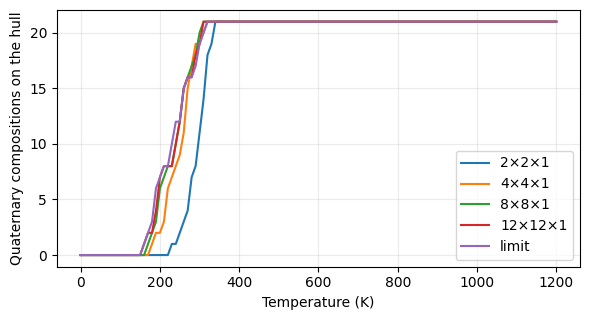

In [10]:
table4, size_hulls = size_sensitivity(vf_metadata, vf_free_energy, temperatures,
                                     base_size=2, sizes=(2, 4, 8, 12, None))
table4.to_csv(output_dir / 'supplementary_table_4.csv', index=False)
display(table4)
fig, ax = plt.subplots(figsize=(6, 3.3))
for size, hull in size_hulls.items():
    quat = vf_metadata.n_elements == 4
    ax.plot(temperatures, hull['on_hull'][quat].sum(axis=0), label='limit' if size is None else f'{size}×{size}×1')
ax.set(xlabel='Temperature (K)', ylabel='Quaternary compositions on the hull')
ax.legend()
ax.grid(alpha=.25)
fig.tight_layout()
plt.show()

In [11]:
vf_441 = cached_441[(cached_441.n_vac_Me == 0) & (cached_441.n_vac_X == 0)]
deficit_441 = entropy_deficits(vf_441, base_size=4, sizes=(4, 8, 12, None))
deficit_441.to_csv(output_dir / 'entropy_deficit_4x4x1.csv', index=False)
print('Ideal entropy deficit over 88 vacancy-free second-inference quaternaries at 1200 K:')
display(deficit_441)
if run_full_gnn:
    gnn_size_summary, gnn_size_hulls = size_sensitivity(
        gnn_metadata, gnn_free_energy, temperatures, base_size=4, sizes=(4, 8, 12, None))
    gnn_size_summary.to_csv(output_dir / 'size_sensitivity_4x4x1.csv', index=False)
    display(gnn_size_summary)
else:
    print('4x4x1 free-energy rescaling requires the optional full GNN run; the ideal deficit does not.')

Ideal entropy deficit over 88 vacancy-free second-inference quaternaries at 1200 K:


,effective_cell,entropy_deficit_mean_meV_atom,entropy_deficit_sd_meV_atom,n_quaternaries
0,4x4x1,5.663572,0.565144,88
1,8x8x1,2.121794,0.147425,88
2,12x12x1,1.133684,0.066042,88
3,limit,0.000000,0.000000,88


4x4x1 free-energy rescaling requires the optional full GNN run; the ideal deficit does not.


<a id="phonon-acceptance-gates"></a>
## Phonon acceptance gates

The raw records in `phonons_results/` contain 25 calculated 12-atom cells: six quaternary targets and their selected tie-plane endmembers. Thermal properties were obtained with phonopy from VASP finite-displacement forces using 3×3×1 supercells and a 31×31×1 q-mesh. The calculation provenance and vacuum geometry are described in the [record guide](phonons_results/README.md).

A cell enters the vibrational table only if all three criteria hold:

- maximum absolute acoustic frequency at Γ < 0.05 THz;
- no mesh mode below −0.05 THz;
- `natom == 12`.

Convert the phonopy thermal free energies from kJ/mol of cells to meV/atom with `10.364269 / natom`, retaining the zero-point part. This stage reads the included YAML outputs; it does not run VASP or phonopy.

In [12]:
fvib, gate_report = build_vibrational_table(root / 'phonons_results')
reference_fvib = pd.read_csv(phonon_data / 'fvib_all.csv').set_index('T')
np.testing.assert_allclose(fvib, reference_fvib, atol=1e-10, rtol=0)
fvib.to_csv(output_dir / 'fvib_all.csv')
gate_report.to_csv(output_dir / 'phonon_gates.csv', index=False)
print(f'{gate_report.accepted.sum()}/{len(gate_report)} cells pass all gates')
display(gate_report)

25/25 cells pass all gates


,cell,gamma_acoustic_THz,modes_below_minus_005_THz,n_atoms,maximum_frequency_THz,accepted
0,Mo4Se2S6,6.909000e-07,0,12,13.210978,True
1,Mo4Se4S4,2.694000e-07,0,12,12.740209,True
2,Mo4Se6S2,4.143000e-07,0,12,11.971884,True
3,Mo4Se8,1.643000e-07,0,12,10.290410,True
4,W1Mo3S8,2.085000e-07,0,12,13.562935,True
5,W1Mo3Se1S7,4.587000e-07,0,12,13.291938,True
6,W1Mo3Se2S6,2.679000e-07,0,12,12.831140,True
7,W1Mo3Se3S5,6.675000e-07,0,12,12.610360,True
8,W1Mo3Se4S4,1.692000e-07,0,12,12.394940,True
9,W1Mo3Se8,2.784000e-07,0,12,10.135148,True


<a id="moving-tie-planes"></a>
## Moving tie planes

For each of the six targets, solve a composition-conserving linear program over the **other vacancy-free compositions** at every temperature. Excluding the target avoids its trivial self-decomposition. The resulting tie planes evolve as the configurational free-energy hull changes.

At and below the onset, a supporting plane defines the decomposition residual

$$\Delta F_{vib}^{d}=F_{vib}^{target}-\sum_i\lambda_iF_{vib}^{i}.$$

Above the onset, the target is a hull vertex and the target-excluded plane describes a competing stability margin. Supporting and competing regimes are accounted for separately. The figure includes every supporting plane and the first competing plane when its phonon data are available.

All 15 supporting planes are computable from the supplied records. Only 7 of the 10 competing planes are computable: `W1Mo3Se5S3` is missing. Missing competing coverage is reported explicitly and does not enter the supporting-plane cancellation argument.

,planes,computed
regime,,
competing,10,7
supporting,15,15


,target,lo,hi,regime,miss
9,W1Mo3Se2S6,310,370,competing,[Mo4Se3S5]
15,W2Mo2Se7S1,490,1200,competing,[W2Mo2Se6S2]
24,W1Mo3Se4S4,400,1200,competing,[W1Mo3Se5S3]


Supporting-plane max |ΔF_vib^d|: 0.082 meV/atom
Supporting-plane max |ΔS_vib^d|: 0.0050 k_B/atom
Affine fit scope: 21 cells (targets + supporting endmembers)


,T,max_affine_residual_meV_atom,bound_2g_meV_atom
0,0,0.130643,0.261286
1,300,0.114393,0.228785
2,1200,0.397943,0.795885


  15 supporting planes drawn, max |dF_vib^d| = 0.082 meV/atom


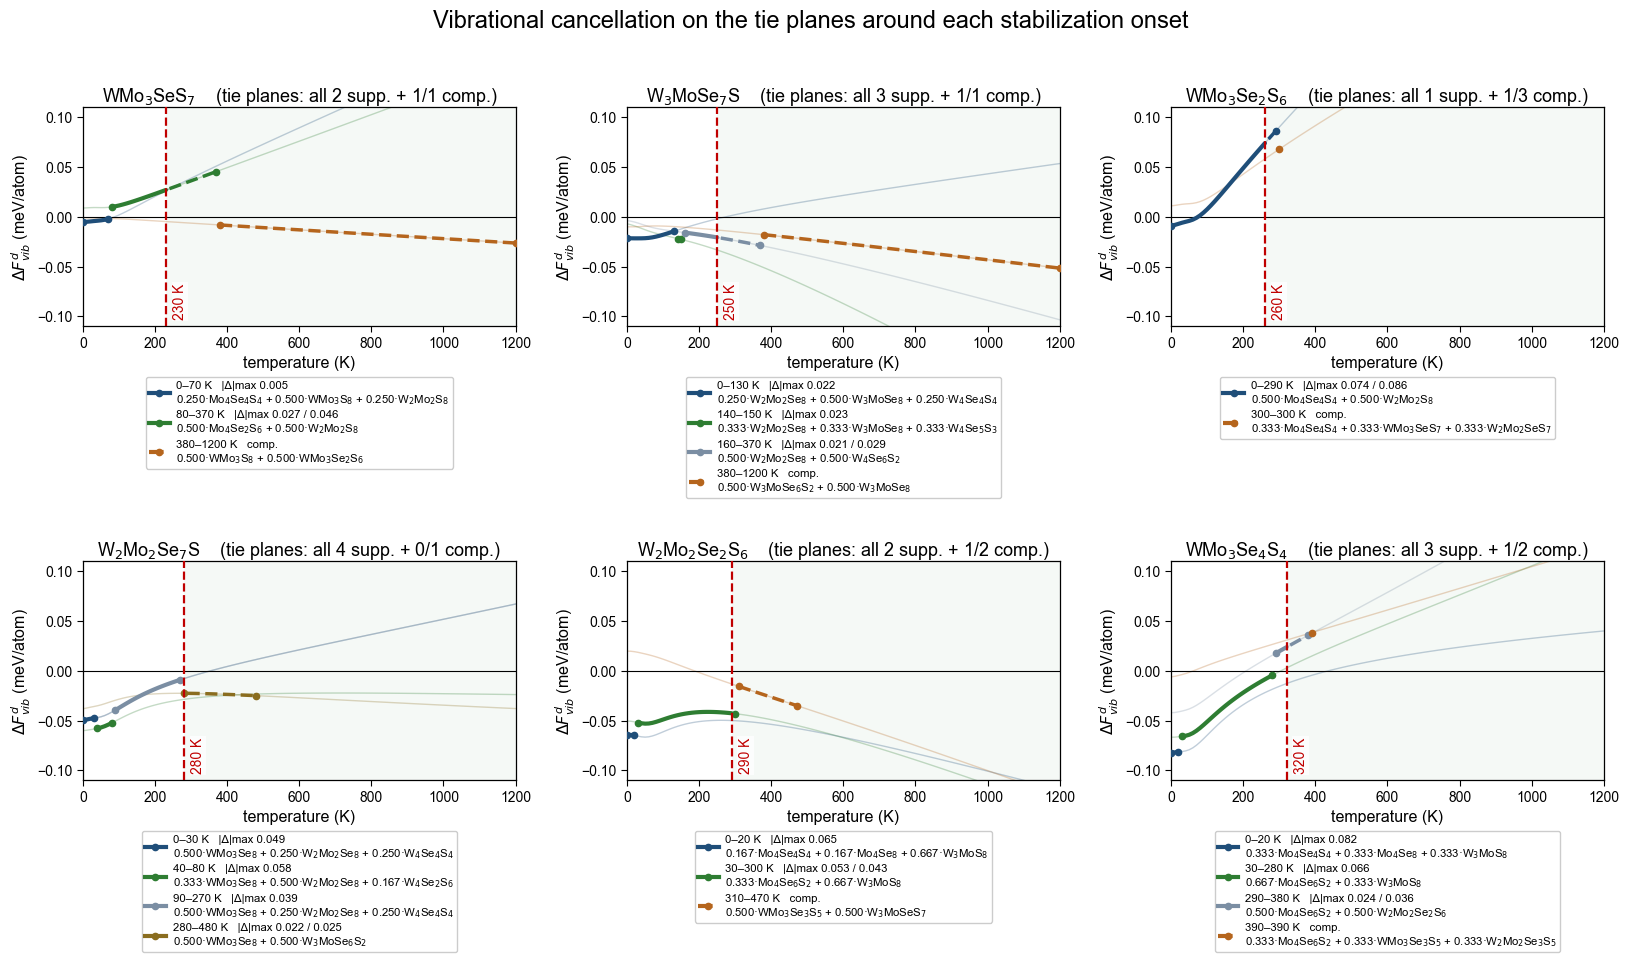

In [13]:
with (phonon_data / 'facets_3window.json').open() as stream:
    target_windows = json.load(stream)
accounting = account_facets(ccs, fvib, target_windows, temperatures)
selected = select_facets(accounting, target_windows)
accounting.to_csv(output_dir / 'facet_accounting.csv', index=False)
with (output_dir / 'facets_by_regime.json').open('w') as stream:
    json.dump(selected, stream, indent=1)
display(accounting.groupby('regime').agg(planes=('ok', 'size'), computed=('ok', 'sum')))
display(accounting.loc[~accounting.ok, ['target', 'lo', 'hi', 'regime', 'miss']])
stats = scoped_statistics(fvib, accounting, selected)
print(f"Supporting-plane max |ΔF_vib^d|: {stats['max_residual_meV_atom']:.3f} meV/atom")
print(f"Supporting-plane max |ΔS_vib^d|: {stats['max_entropy_kB_atom']:.4f} k_B/atom")
print(f"Affine fit scope: {stats['n_scope']} cells (targets + supporting endmembers)")
display(stats['affine_bounds'])
fig = plot_vibrational(fvib, selected, output_dir)
display(fig)
plt.close(fig)

<a id="onset-shifts"></a>
## Onset shifts

Supplementary Table 5 uses the supporting plane active at each onset to estimate the vibrational shift in two ways:

- **Eq. (6):** $T_0[(1+\Delta S_{vib}/\Delta S_{conf})^{-1}-1]$, with central differences on the 10 K grid.
- **Direct estimate:** $-\Delta F_{vib}^{d}(T_0)/(d\Delta G_{hull}/dT)$, retaining the zero-point residual and using a backward 40 K slope of the rounded vacancy-free hull table.

These estimates differ in both numerator and denominator; neither is a full recomputation of the vibrationally corrected hull. The 40 K slope window was recovered by matching the supplied publication values because the original direct-shift script did not survive. Use the original rounded hull export here to preserve that reconstruction.

The supplied shifts span −2.3 to +10.3 K for Eq. (6) and −4.0 to +8.7 K for the direct estimate.

In [14]:
table5 = onset_shifts(ccs, fvib, selected, reference_vf, temperatures)
reference_table5 = pd.read_csv(phonon_data / 'supplementary_table_5.csv')
numeric_columns = reference_table5.select_dtypes('number').columns
np.testing.assert_allclose(table5[numeric_columns], reference_table5[numeric_columns], atol=5.1e-5, rtol=0)
table5.to_csv(output_dir / 'supplementary_table_5.csv', index=False, float_format='%.4f')
display(table5)

,composition,onset_K,tie_plane,dFvib_at_onset_meV_atom,dSvib_1e3_kB_atom,dSconf_1e3_kB_atom,ratio_pct,shift_eq6_K,shift_direct_K
0,WMo3SeS7,230.0,0.500 Mo4Se2S6 + 0.500 W2Mo2S8,0.027067,-1.518639,72.820166,-2.085465,4.898730,5.647734
1,W3MoSe7S,250.0,0.500 W2Mo2Se8 + 0.500 W4Se6S2,-0.020612,0.702516,77.323709,0.908539,-2.250896,-3.971522
2,WMo3Se2S6,260.0,0.500 Mo4Se4S4 + 0.500 W2Mo2S8,0.074084,-4.742790,124.073638,-3.822560,10.333668,8.672460
3,W2Mo2Se7S,280.0,0.500 WMo3Se8 + 0.500 W3MoSe6S2,-0.022483,0.026109,72.691870,0.035918,-0.100533,-1.977354
4,W2Mo2Se2S6,290.0,0.333 Mo4Se6S2 + 0.667 W3MoS8,-0.042545,0.450412,237.427618,0.189705,-0.549103,-2.102792
5,WMo3Se4S4,320.0,0.500 Mo4Se6S2 + 0.500 W2Mo2Se2S6,0.023854,-2.348067,108.575818,-2.162606,7.073307,2.027986


<a id="exported-results"></a>
## Exported results

The long-format 2×2×1 tables contain composition, temperature, configurational free energy, moving hull reference, distance above hull, hull membership, configuration counts and symmetry-weight sums. All three free-energy columns are **eV/atom**. Wide `dGhull_*` tables, vibrational tables and figure axes use **meV/atom**.

The default run writes regenerated tables and four PNG/PDF figure pairs to the output directory. The optional full GNN run also retains the existing `data/inference2_ccs-finite_temperature_hull.pkl.gz` export for downstream work. Figure bytes may depend on fonts and library versions.

In [15]:
full_results = long_result_table(full_metadata, full_free_energy, full_hull, temperatures)
vf_results = long_result_table(vf_metadata, vf_free_energy, vf_hull, temperatures)
full_results.to_csv(output_dir / 'finite_temperature_2x2x1.csv', index=False)
vf_results.to_csv(output_dir / 'finite_temperature_2x2x1_vacancyfree.csv', index=False)
run_metadata = {
    'temperature_step_K': 10, 'hull_tolerance_eV_atom': hull_tolerance,
    'energy_columns': 'eV/atom; dGhull and F_vib reporting tables use meV/atom',
    'full_gnn_recomputed': run_full_gnn,
    'dft_minimum_correction': apply_dft_minimum_correction if run_full_gnn else 'included 4x4 cache is DFT-anchored',
    'sizes_are_estimates': True, 'direct_onset_slope_window_K': 40,
}
with (output_dir / 'run_metadata.json').open('w') as stream:
    json.dump(run_metadata, stream, indent=2)
print(f'Exported {len(full_results):,} full-hull and {len(vf_results):,} vacancy-free rows')
display(pd.DataFrame({'generated_file': sorted(p.name for p in output_dir.iterdir() if p.is_file())}))

Exported 50,820 full-hull and 5,445 vacancy-free rows


,generated_file
0,entropy_deficit_4x4x1.csv
1,facet_accounting.csv
2,facets_by_regime.json
3,fig441_6d_MoW.pdf
4,fig441_6d_MoW.png
5,fig441_6d_SSe.pdf
6,fig441_6d_SSe.png
7,figure_dfvib_onset_window.pdf
8,figure_dfvib_onset_window.png
9,figure_quaternary_onhull_vacancyfree.pdf
